In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("student_data.csv")

In [8]:
print("Columns:")
print(df.columns)

Columns:
Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


In [9]:
X = df[["studytime", "absences", "G1", "G2"]]
y = df["G3"]

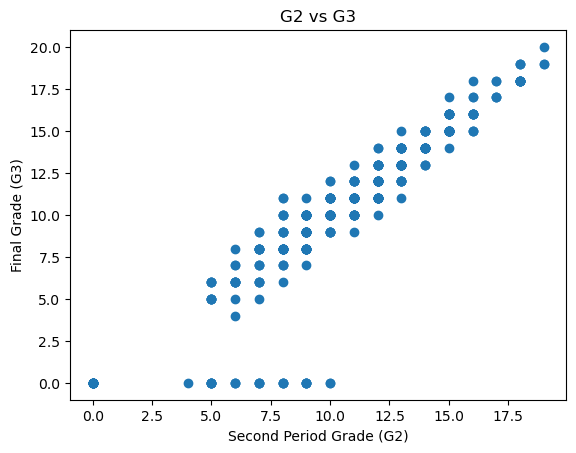

In [10]:
plt.scatter(df["G2"], df["G3"])
plt.xlabel("Second Period Grade (G2)")
plt.ylabel("Final Grade (G3)")
plt.title("G2 vs G3")
plt.show()

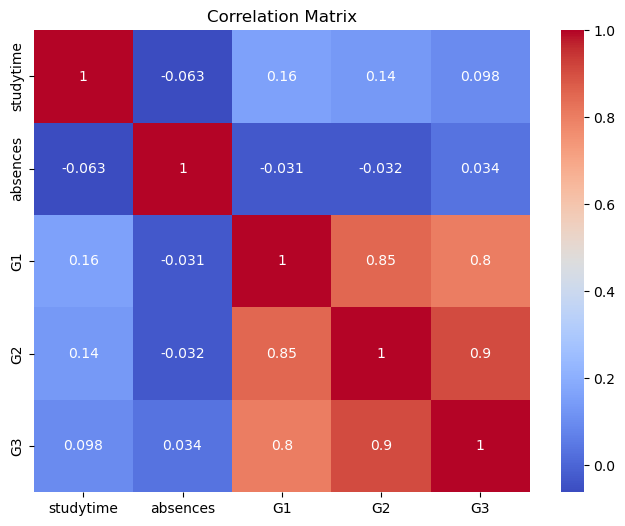

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(df[["studytime","absences","G1","G2","G3"]].corr(),
            annot=True,
            cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [14]:
y_pred = model.predict(X_test)

In [15]:
print("\nModel Performance:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


Model Performance:
MAE: 1.3125749396243545
MSE: 4.178975406386834
R2 Score: 0.7961977189442986


In [21]:
import pandas as pd

new_data = pd.DataFrame(
    [[3, 5, 12, 13]],
    columns=["studytime", "absences", "G1", "G2"]
)

predicted = model.predict(new_data)

print("\nPredicted Final Grade (G3):", predicted[0])


Predicted Final Grade (G3): 12.757249265704202


In [22]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest R2:",
      r2_score(y_test, rf_pred))

Random Forest R2: 0.8408819985691713


In [23]:
from sklearn.metrics import r2_score

# Linear Regression R2
lr_r2 = r2_score(y_test, y_pred)

# Random Forest R2
rf_r2 = r2_score(y_test, rf_pred)

print("Linear Regression R2:", lr_r2)
print("Random Forest R2:", rf_r2)

Linear Regression R2: 0.7961977189442986
Random Forest R2: 0.8408819985691713


In [24]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance)

     Feature  Importance
3         G2    0.820176
1   absences    0.123856
2         G1    0.032097
0  studytime    0.023871


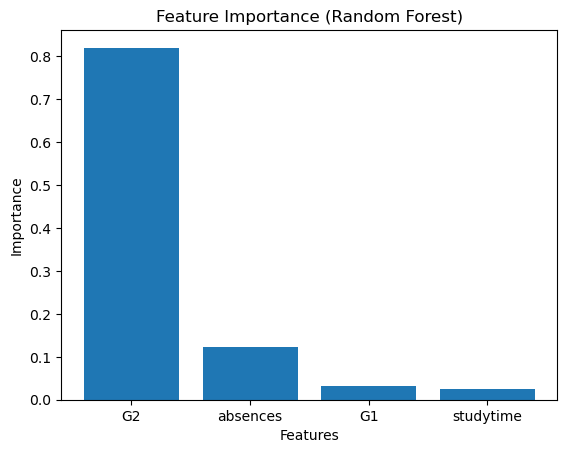

In [25]:
import matplotlib.pyplot as plt

plt.bar(importance["Feature"], importance["Importance"])
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.show()

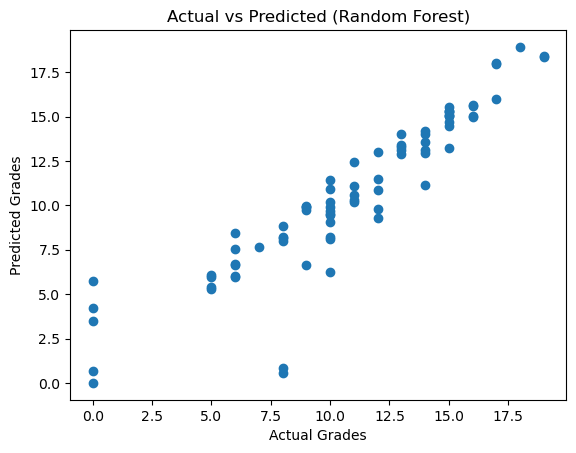

In [26]:
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Grades")
plt.ylabel("Predicted Grades")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()